# Quantum Fourier Transform

In [ ]:
!pip install qiskit
# Reiniciar kernel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 11.3 MB/s eta 0:00:00


In [ ]:
pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 63.8 MB/s eta 0:00:00


In [ ]:
pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=9f3de9c7b40a69bab99b2526c35487dccfff0ba6118db8cc44fac70743050645
  Stored in directory: /root/.cache/pip/wheels/b1/7a/33/9fdd892f784ed4afda62b685ae3703adf4c91aa0f524c28f03
Successfully built pylatexenc


In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector, partial_trace, DensityMatrix
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt


# **QFT**


# 1. Preparación del estado

In [ ]:
def crear_circuito(n_qubits,n_bits):
  # Crear registros de cada cúbit con subíndice
  q = QuantumRegister(n_qubits,name="q")

  # Crear registros clásicos para almacenar mediciones
  c = ClassicalRegister(n_bits)

  # Crear el circuito con los tres cúbits
  qc = QuantumCircuit(q,c)
  return qc, q, c

In [ ]:
def inicializar_estado(estado, qc, q):
  for ind, i in enumerate(estado):
    if(i == '1'):
      qc.x(q[n_qubits-ind-1])

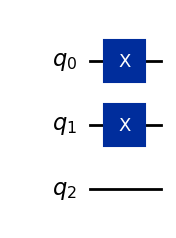

In [ ]:
n_qubits = 3
qc, q, c= crear_circuito(n_qubits, 0)
# Estado que se desea mandar
estado_psi = '011'


inicializar_estado(estado_psi, qc, q)

# Visualizar el circuito
qc.draw('mpl')

# 2. QFT


In [ ]:
def QFT(qc, q, n_qubits):
  for ind in range(n_qubits - 1, -1, -1):
    qc.h(q[ind])
    for j in range(ind - 1, -1, -1):
      qc.cp(np.pi / 2 ** (ind - j), q[j], q[ind])

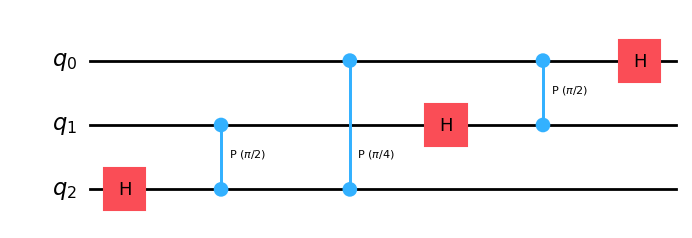

In [ ]:
qc, q, c = crear_circuito(n_qubits,0)
QFT(qc, q, n_qubits)

# Visualizar el circuito
qc.draw('mpl')

# 3. Inversa QFT


In [ ]:
def QFT_inversa(qc, q, n_qubits):
  for ind in range(n_qubits):
    for j in range(ind,0,-1):
      qc.cp(-np.pi / 2 ** (1+ind - j), q[j-1], q[ind])
    qc.h(q[ind])

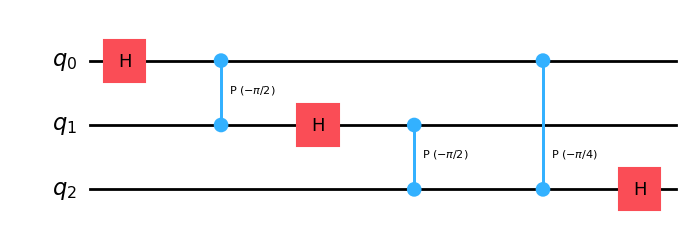

In [ ]:
qc, q, c = crear_circuito(n_qubits,0)
QFT_inversa(qc, q, n_qubits)

# Visualizar el circuito
qc.draw('mpl')

# 4. Cambio de posición



In [ ]:
def cambio_estado(qc, q, n_qubits):
  for ind in range(int(n_qubits/2)):
    qc.swap(ind,n_qubits-ind-1)


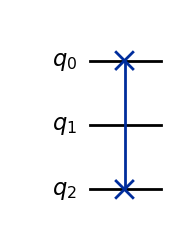

In [ ]:
qc, q, c = crear_circuito(n_qubits,0)
cambio_estado(qc, q, n_qubits)
qc.draw('mpl')
